In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.sparse import lil_matrix, csr_matrix, diags
from scipy.sparse.linalg import spsolve, cg
from mpl_toolkits.mplot3d import Axes3D

# Zadanie 1 - Rownanie eliptyczne (Poisson)

Rownnanie Poissona opisuje odksztalcenia elastycznej membrany:

$$u_{xx} + u_{yy} = 8\pi^2 \sin(2\pi x)\cos(2\pi y)$$

Warunki brzegowe: $u(0,y)=u(1,y)=0$, $u(x,0)=u(x,1)=\sin(2\pi x)$

Dokladne rozwiazanie: $u(x,y) = \sin(2\pi x)\cos(2\pi y)$

In [2]:
# 1a - Operator pieciopunktowy (Five-Point Stencil)
# Rownanie Poissona: u_xx + u_yy = f
# Schemat FDM: (u_{i+1,j}+u_{i-1,j}+u_{i,j+1}+u_{i,j-1} - 4*u_{i,j}) / h^2 = f(x_i,y_j)
# Dokladne rozwiazanie u = sin(2pi*x)*cos(2pi*y) spelnia:
#   u_xx + u_yy = -4pi^2*sin*cos - 4pi^2*sin*cos = -8pi^2*sin*cos
# Wiec funkcja prawej strony: f(x,y) = -8*pi^2*sin(2pi*x)*cos(2pi*y)
# (w poleceniu wartosc bezwzgledna |f| = 8pi^2, co jest podane jako czesc zadania)

def build_poisson_system(h):
    N = int(round(1/h)) - 1        # wezly wewnetrzne w kazdym kierunku
    n_dof = N * N

    def f(x, y):
        # Prawa strona rownania Poissona: f = u_xx + u_yy dla u=sin(2pi*x)cos(2pi*y)
        return -8.0 * np.pi**2 * np.sin(2*np.pi*x) * np.cos(2*np.pi*y)

    def g(x, y):
        # Warunek brzegowy = dokladne rozwiazanie na krawedzi
        return np.sin(2*np.pi*x) * np.cos(2*np.pi*y)

    A = lil_matrix((n_dof, n_dof))
    b = np.zeros(n_dof)

    for i in range(N):
        xi = (i + 1) * h
        for j in range(N):
            yj = (j + 1) * h
            k  = i * N + j

            A[k, k] = -4.0
            b[k] = h**2 * f(xi, yj)

            # Sasiad x+
            if i + 1 < N: A[k, (i+1)*N + j] = 1.0
            else:          b[k] -= g(1.0, yj)

            # Sasiad x-
            if i - 1 >= 0: A[k, (i-1)*N + j] = 1.0
            else:           b[k] -= g(0.0, yj)

            # Sasiad y+
            if j + 1 < N: A[k, i*N + (j+1)] = 1.0
            else:          b[k] -= g(xi, 1.0)

            # Sasiad y-
            if j - 1 >= 0: A[k, i*N + (j-1)] = 1.0
            else:           b[k] -= g(xi, 0.0)

    return csr_matrix(A), b, N

H = 0.1
A_mat, b_vec, N = build_poisson_system(H)
print(f"h = {H}, N = {N}, rozmiar ukladu: {N**2} x {N**2}")
print(f"Macierz A - niezerowych: {A_mat.nnz}, gestosc: {A_mat.nnz/N**4*100:.2f}%")


h = 0.1, N = 9, rozmiar ukladu: 81 x 81
Macierz A - niezerowych: 369, gestosc: 5.62%


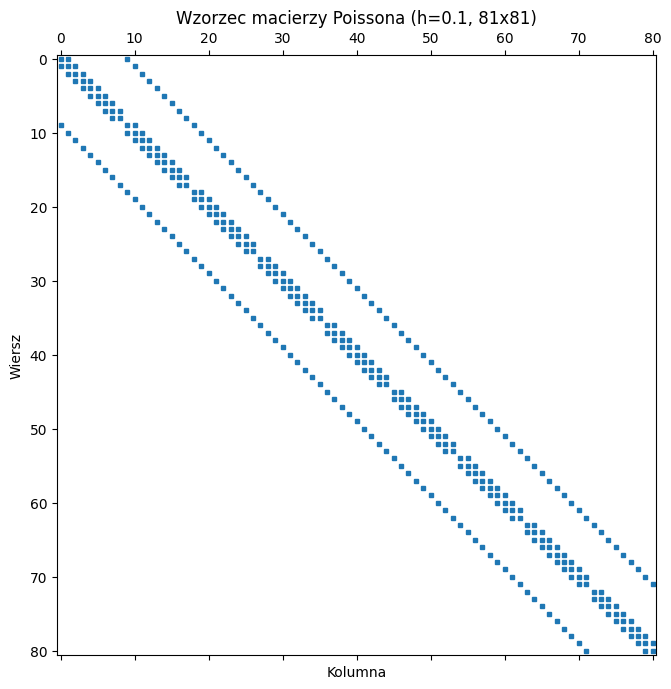

Struktura: bloki trojdiagonalne, -4 na diagonali, 1 na sasiadach.


In [3]:
# 1b - Wzorzec niezerowych elementow macierzy (spy plot)
fig, ax = plt.subplots(figsize=(7, 7))
ax.spy(A_mat, markersize=3)
ax.set_title(f"Wzorzec macierzy Poissona (h={H}, {N**2}x{N**2})")
ax.set_xlabel("Kolumna"); ax.set_ylabel("Wiersz")
plt.tight_layout(); plt.show()
print("Struktura: bloki trojdiagonalne, -4 na diagonali, 1 na sasiadach.")

CG status: 0 (0=zbieznosc)
CG iteracji: 5
CG residuum koncowe: 1.83e-14


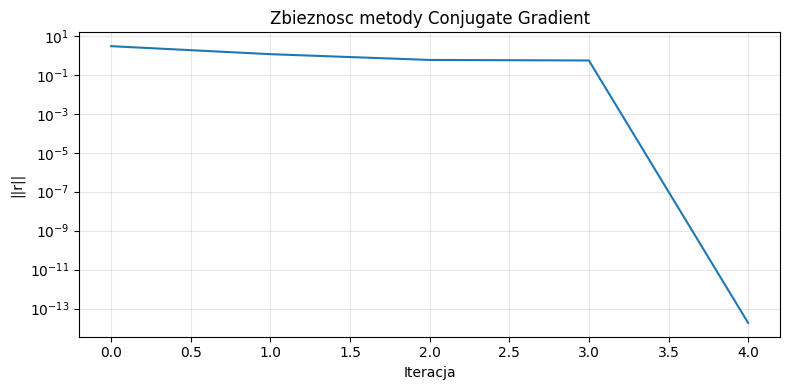

In [4]:
# 1c - Rozwiazanie iteracyjne: Conjugate Gradient (CG)
# Macierz A jest ujemnie okreslona (wartosci wlasne < 0),
# wiec przeksztalcamy: (-A)*u = (-b) -> macierz -A jest SPD

residuals = []

def callback_cg(xk):
    r = (-b_vec) - (-A_mat) @ xk
    residuals.append(np.linalg.norm(r))

u_cg, info = cg(-A_mat, -b_vec, rtol=1e-10, maxiter=1000, callback=callback_cg)

print(f"CG status: {info} (0=zbieznosc)")
print(f"CG iteracji: {len(residuals)}")
if residuals:
    print(f"CG residuum koncowe: {residuals[-1]:.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(residuals)
ax.set_xlabel("Iteracja"); ax.set_ylabel("||r||")
ax.set_title("Zbieznosc metody Conjugate Gradient")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


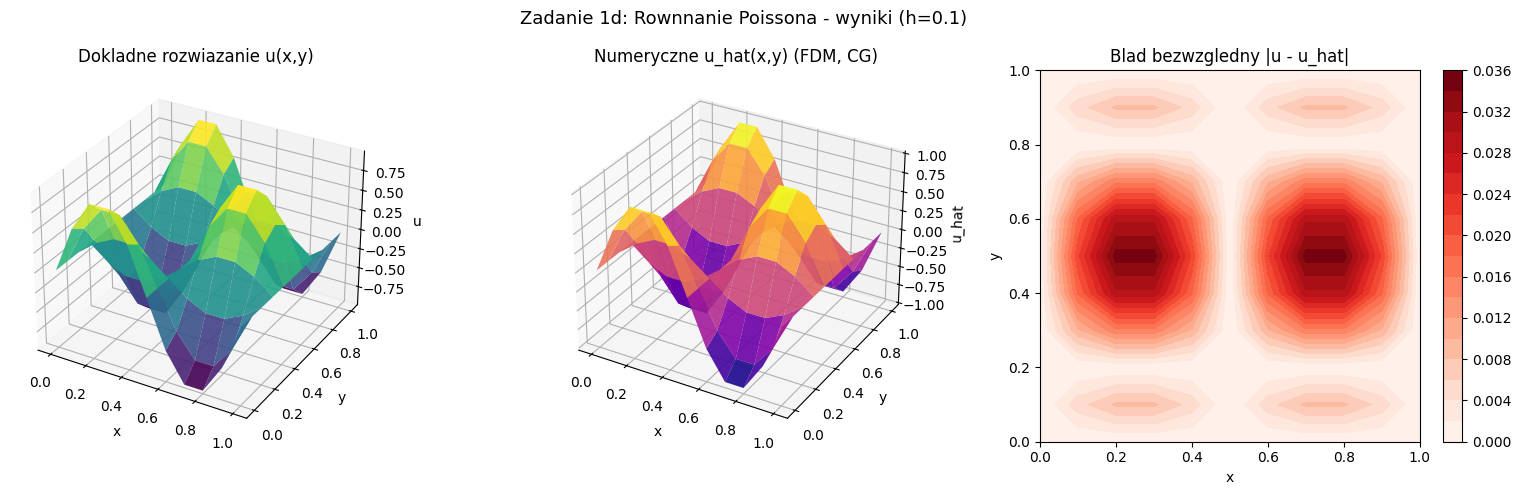

Max blad bezwzgledny (h=0.1): 3.4953e-02
Sr.  blad bezwzgledny (h=0.1): 7.5855e-03


In [5]:
# 1d - Wykresy: dokladne vs numeryczne rozwiazanie + blad

def exact_u(x, y):
    return np.sin(2*np.pi*x) * np.cos(2*np.pi*y)

x_all = np.linspace(0, 1, N+2)
y_all = np.linspace(0, 1, N+2)
X_all, Y_all = np.meshgrid(x_all, y_all, indexing="ij")

U_exact = exact_u(X_all, Y_all)

# Rozwiazanie numeryczne z warunkami brzegowymi
U_num = np.zeros((N+2, N+2))
U_num[0, :]  = exact_u(0,     y_all)
U_num[-1, :] = exact_u(1,     y_all)
U_num[:, 0]  = exact_u(x_all, 0)
U_num[:, -1] = exact_u(x_all, 1)
for i in range(N):
    for j in range(N):
        U_num[i+1, j+1] = u_cg[i*N + j]

Error = np.abs(U_num - U_exact)

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(131, projection="3d")
ax1.plot_surface(X_all, Y_all, U_exact, cmap="viridis", alpha=0.9)
ax1.set_title("Dokladne rozwiazanie u(x,y)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("u")

ax2 = fig.add_subplot(132, projection="3d")
ax2.plot_surface(X_all, Y_all, U_num, cmap="plasma", alpha=0.9)
ax2.set_title("Numeryczne u_hat(x,y) (FDM, CG)")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("u_hat")

ax3 = fig.add_subplot(133)
cp = ax3.contourf(X_all, Y_all, Error, levels=20, cmap="Reds")
plt.colorbar(cp, ax=ax3)
ax3.set_title("Blad bezwzgledny |u - u_hat|")
ax3.set_xlabel("x"); ax3.set_ylabel("y")

plt.suptitle("Zadanie 1d: Rownnanie Poissona - wyniki (h=0.1)", fontsize=13)
plt.tight_layout(); plt.show()

print(f"Max blad bezwzgledny (h={H}): {Error.max():.4e}")
print(f"Sr.  blad bezwzgledny (h={H}): {Error.mean():.4e}")


h = 0.25000: max blad = 2.6709e-01
h = 0.12500: max blad = 5.8342e-02
h = 0.06250: max blad = 1.4113e-02
h = 0.03125: max blad = 3.4994e-03
h = 0.01562: max blad = 8.7307e-04
  Rzad miedzy h=0.2500 a h=0.1250: p = 2.19
  Rzad miedzy h=0.1250 a h=0.0625: p = 2.05
  Rzad miedzy h=0.0625 a h=0.0312: p = 2.01
  Rzad miedzy h=0.0312 a h=0.0156: p = 2.00

Sredni empiryczny rzad zbieznosci: 2.06
(Oczekiwany dla 5-punktowego: p = 2)


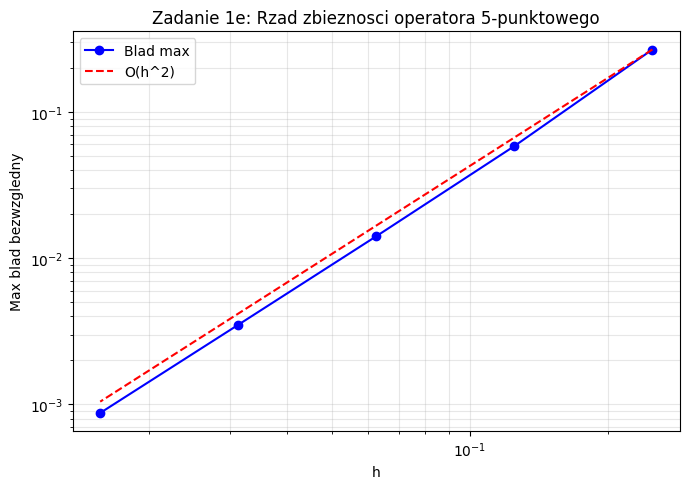

In [6]:
# 1e - Empiryczny rzad zbieznosci operatora 5-punktowego

h_values  = [1/4, 1/8, 1/16, 1/32, 1/64]
max_errors = []

for h in h_values:
    A_h, b_h, Nh = build_poisson_system(h)
    # Macierz -A_h jest SPD - rozwiazujemy uklad (-A)*u = -b
    u_h, _ = cg(-A_h, -b_h, rtol=1e-12, maxiter=10000)
    errs = [abs(u_h[i*Nh+j] - exact_u((i+1)*h, (j+1)*h))
            for i in range(Nh) for j in range(Nh)]
    err = max(errs)
    max_errors.append(err)
    print(f"h = {h:.5f}: max blad = {err:.4e}")

orders = []
for i in range(1, len(h_values)):
    p = np.log(max_errors[i-1]/max_errors[i]) / np.log(h_values[i-1]/h_values[i])
    orders.append(p)
    print(f"  Rzad miedzy h={h_values[i-1]:.4f} a h={h_values[i]:.4f}: p = {p:.2f}")

print(f"\nSredni empiryczny rzad zbieznosci: {np.mean(orders):.2f}")
print("(Oczekiwany dla 5-punktowego: p = 2)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(h_values, max_errors, "bo-", label="Blad max")
h_ref = np.array(h_values)
ax.loglog(h_ref, h_ref**2 * max_errors[0]/h_values[0]**2, "r--", label="O(h^2)")
ax.set_xlabel("h"); ax.set_ylabel("Max blad bezwzgledny")
ax.set_title("Zadanie 1e: Rzad zbieznosci operatora 5-punktowego")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


# Zadanie 2 - Rownanie paraboliczne (cieplo)

Rownnanie przewodnictwa ciepla:
$$u_t = u_{xx}, \quad 0 \le x \le 1, \quad t \ge 0$$

Warunki poczatkowe (funkcja namiotowa):
$$u(0,x) = \begin{cases} 2x & x \le 0.5 \\ 2-2x & x > 0.5 \end{cases}$$

Warunki brzegowe: $u(t,0) = u(t,1) = 0$

=== 2a: dt=0.0012 ===
  dx=0.05, dt=0.0012, r=dt/dx^2=0.4800 ( STABILNA )


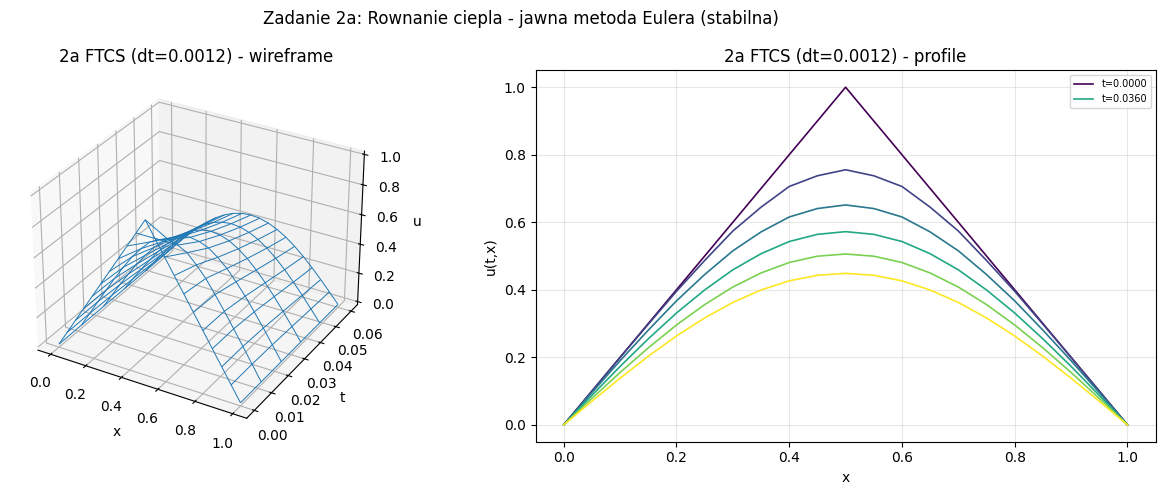

In [7]:
# 2a - Jawna metoda Eulera (FTCS)
# u_i^{k+1} = u_i^k + r*(u_{i+1}^k - 2*u_i^k + u_{i-1}^k)
# Warunek stabilnosci von Neumanna: r = dt/dx^2 <= 0.5

dx    = 0.05
dt_s  = 0.0012
T_end = 0.06

def heat_init(x):
    return np.where(x <= 0.5, 2*x, 2 - 2*x)

def solve_explicit(dx, dt, T_end):
    xs = np.arange(0, 1 + dx/2, dx)
    Nx = len(xs)
    Nt = int(round(T_end / dt)) + 1
    r  = dt / dx**2
    print(f"  dx={dx}, dt={dt}, r=dt/dx^2={r:.4f} (", "STABILNA" if r <= 0.5 else "NIESTABILNA", ")")
    U = np.zeros((Nt, Nx))
    U[0] = heat_init(xs)
    U[0, 0] = U[0, -1] = 0.0
    for k in range(Nt - 1):
        U[k+1, 1:-1] = U[k, 1:-1] + r*(U[k, 2:] - 2*U[k, 1:-1] + U[k, :-2])
        U[k+1, 0] = U[k+1, -1] = 0.0
    return xs, U

print("=== 2a: dt=0.0012 ===")
xs_a, U_a = solve_explicit(dx, dt_s, T_end)

ts_a = np.arange(0, U_a.shape[0]) * dt_s
steps = list(range(0, U_a.shape[0], 10))

fig = plt.figure(figsize=(13, 5))

# Wireframe 3D
ax1 = fig.add_subplot(121, projection="3d")
Xm, Tm = np.meshgrid(xs_a, ts_a[steps])
ax1.plot_wireframe(Xm, Tm, U_a[steps, :], rstride=1, cstride=1, linewidth=0.7)
ax1.set_xlabel("x"); ax1.set_ylabel("t"); ax1.set_zlabel("u")
ax1.set_title(f"2a FTCS (dt={dt_s}) - wireframe")

# Profile kolorowe
ax2 = fig.add_subplot(122)
colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))
for idx, (s, c) in enumerate(zip(steps, colors)):
    lbl = f"t={ts_a[s]:.4f}" if idx % 3 == 0 else ""
    ax2.plot(xs_a, U_a[s], color=c, lw=1.2, label=lbl)
ax2.set_xlabel("x"); ax2.set_ylabel("u(t,x)")
ax2.set_title(f"2a FTCS (dt={dt_s}) - profile")
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

plt.suptitle("Zadanie 2a: Rownanie ciepla - jawna metoda Eulera (stabilna)", fontsize=12)
plt.tight_layout(); plt.show()

=== 2b: dt=0.0013 (niestabilna) ===
  dx=0.05, dt=0.0013, r=dt/dx^2=0.5200 ( NIESTABILNA )


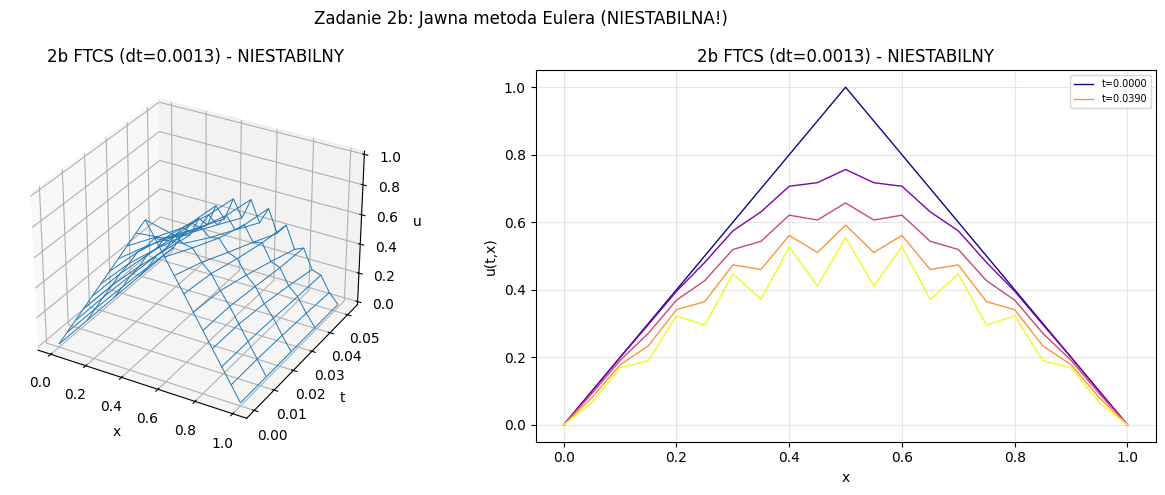


Wyjasnienie:
  Warunek stabilnosci von Neumanna: r = dt/dx^2 <= 0.5
  dt=0.0012 -> r = 0.4800 (stabilna)
  dt=0.0013 -> r = 0.5200 (NIESTABILNA, r > 0.5!)
  Naruszenie warunku powoduje wykladniczy wzrost bledow (numeryczna eksplozja).


In [8]:
# 2b - Jawna metoda Eulera z dt=0.0013 (NIESTABILNA, r > 0.5)

dt_u = 0.0013
print("=== 2b: dt=0.0013 (niestabilna) ===")
xs_b, U_b = solve_explicit(dx, dt_u, T_end)

ts_b  = np.arange(0, U_b.shape[0]) * dt_u
steps_b = list(range(0, U_b.shape[0], 10))

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121, projection="3d")
Xm2, Tm2 = np.meshgrid(xs_b, ts_b[steps_b])
ax1.plot_wireframe(Xm2, Tm2, U_b[steps_b, :], rstride=1, cstride=1, linewidth=0.7)
ax1.set_xlabel("x"); ax1.set_ylabel("t"); ax1.set_zlabel("u")
ax1.set_title(f"2b FTCS (dt={dt_u}) - NIESTABILNY")

ax2 = fig.add_subplot(122)
colors2 = plt.cm.plasma(np.linspace(0, 1, len(steps_b)))
for idx, (s, c) in enumerate(zip(steps_b, colors2)):
    lbl = f"t={ts_b[s]:.4f}" if idx % 3 == 0 else ""
    ax2.plot(xs_b, U_b[s], color=c, lw=1.0, label=lbl)
ax2.set_xlabel("x"); ax2.set_ylabel("u(t,x)")
ax2.set_title(f"2b FTCS (dt={dt_u}) - NIESTABILNY")
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

plt.suptitle("Zadanie 2b: Jawna metoda Eulera (NIESTABILNA!)", fontsize=12)
plt.tight_layout(); plt.show()

r_u = dt_u / dx**2
print(f"\nWyjasnienie:")
print(f"  Warunek stabilnosci von Neumanna: r = dt/dx^2 <= 0.5")
print(f"  dt=0.0012 -> r = {0.0012/dx**2:.4f} (stabilna)")
print(f"  dt=0.0013 -> r = {r_u:.4f} (NIESTABILNA, r > 0.5!)")
print("  Naruszenie warunku powoduje wykladniczy wzrost bledow (numeryczna eksplozja).")

=== 2c: Niejawna metoda Eulera (dt=0.005) ===
  dx=0.05, dt=0.005, r=2.0000 (niejawna - zawsze stabilna)


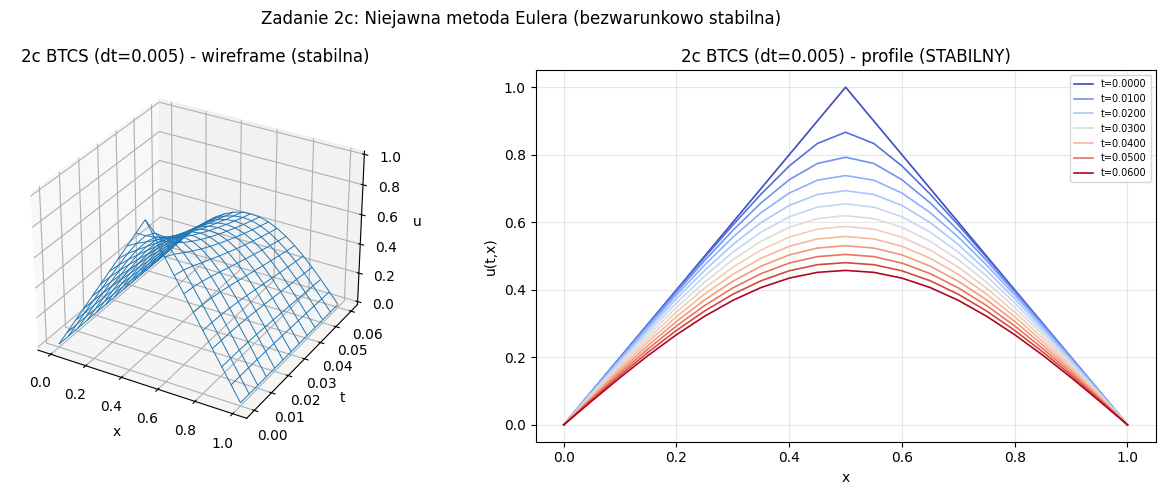


Podsumowanie:
  Jawna  FTCS: wymaga dt <= 0.00125 (r <= 0.5)
  Niejawna BTCS: stabilna dla dowolnego dt
  Koszt: rozwiazywanie trojdiagonalnego ukladu O(N) w kazdym kroku.


In [9]:
# 2c - Niejawna metoda Eulera (BTCS: Backward Time, Central Space)
# u_i^{k+1} - r*(u_{i+1}^{k+1} - 2*u_i^{k+1} + u_{i-1}^{k+1}) = u_i^k
# Macierz trojdiagonalna (I - r*D^2) * u^{k+1} = u^k
# Metoda niejawna jest bezwarunkowo stabilna!

def solve_implicit(dx, dt, T_end):
    xs = np.arange(0, 1 + dx/2, dx)
    Nx = len(xs)
    Nt = int(round(T_end / dt)) + 1
    r  = dt / dx**2
    N_int = Nx - 2
    print(f"  dx={dx}, dt={dt}, r={r:.4f} (niejawna - zawsze stabilna)")

    d_main = np.full(N_int, 1 + 2*r)
    d_off  = np.full(N_int - 1, -r)
    M = diags([d_off, d_main, d_off], [-1, 0, 1], format="csr")

    U = np.zeros((Nt, Nx))
    U[0] = heat_init(xs)
    U[0, 0] = U[0, -1] = 0.0

    for k in range(Nt - 1):
        rhs = U[k, 1:-1].copy()
        U[k+1, 1:-1] = spsolve(M, rhs)
        U[k+1, 0] = U[k+1, -1] = 0.0

    return xs, U

dt_imp = 0.005
print("=== 2c: Niejawna metoda Eulera (dt=0.005) ===")
xs_c, U_c = solve_implicit(dx, dt_imp, T_end)

ts_c  = np.arange(0, U_c.shape[0]) * dt_imp
steps_c = list(range(U_c.shape[0]))

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121, projection="3d")
Xmc, Tmc = np.meshgrid(xs_c, ts_c[steps_c])
ax1.plot_wireframe(Xmc, Tmc, U_c[steps_c, :], rstride=1, cstride=1, linewidth=0.7)
ax1.set_xlabel("x"); ax1.set_ylabel("t"); ax1.set_zlabel("u")
ax1.set_title(f"2c BTCS (dt={dt_imp}) - wireframe (stabilna)")

ax2 = fig.add_subplot(122)
colors3 = plt.cm.coolwarm(np.linspace(0, 1, len(steps_c)))
for idx, (s, c) in enumerate(zip(steps_c, colors3)):
    lbl = f"t={ts_c[s]:.4f}" if idx % 2 == 0 else ""
    ax2.plot(xs_c, U_c[s], color=c, lw=1.2, label=lbl)
ax2.set_xlabel("x"); ax2.set_ylabel("u(t,x)")
ax2.set_title(f"2c BTCS (dt={dt_imp}) - profile (STABILNY)")
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

plt.suptitle("Zadanie 2c: Niejawna metoda Eulera (bezwarunkowo stabilna)", fontsize=12)
plt.tight_layout(); plt.show()

print("\nPodsumowanie:")
print(f"  Jawna  FTCS: wymaga dt <= {0.5*dx**2:.5f} (r <= 0.5)")
print(f"  Niejawna BTCS: stabilna dla dowolnego dt")
print("  Koszt: rozwiazywanie trojdiagonalnego ukladu O(N) w kazdym kroku.")

=== 2d: Metoda Cranka-Nicolson (dt=0.005) ===
  dx=0.05, dt=0.005, r=2.0000 (Crank-Nicolson)


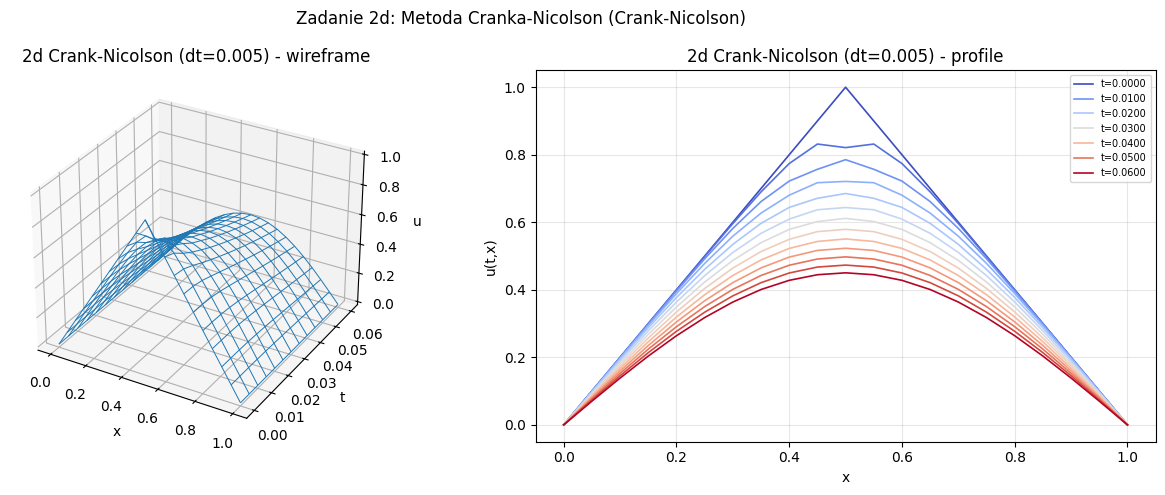

In [10]:
# 2d - Metoda Cranka-Nicolson (Crank-Nicolson Method)
# u_i^{k+1} - r/2 * (u_{i+1}^{k+1} - 2*u_i^{k+1} + u_{i-1}^{k+1}) = u_i^k + r/2 * (u_{i+1}^k - 2*u_i^k + u_{i-1}^k)
# Bezwarunkowo stabilna, rzad zbieznosci O(dt^2 + dx^2)

def solve_crank_nicolson(dx, dt, T_end):
    xs = np.arange(0, 1 + dx/2, dx)
    Nx = len(xs)
    Nt = int(round(T_end / dt)) + 1
    r  = dt / dx**2
    N_int = Nx - 2
    print(f"  dx={dx}, dt={dt}, r={r:.4f} (Crank-Nicolson)")

    # Macierz lewej strony (LHS): I - r/2 * D^2
    d_main_LHS = np.full(N_int, 1 + r)
    d_off_LHS  = np.full(N_int - 1, -r / 2.0)
    M_LHS = diags([d_off_LHS, d_main_LHS, d_off_LHS], [-1, 0, 1], format="csr")

    # Macierz prawej strony (RHS): I + r/2 * D^2
    d_main_RHS = np.full(N_int, 1 - r)
    d_off_RHS  = np.full(N_int - 1, r / 2.0)
    M_RHS = diags([d_off_RHS, d_main_RHS, d_off_RHS], [-1, 0, 1], format="csr")

    U = np.zeros((Nt, Nx))
    U[0] = heat_init(xs)
    U[0, 0] = U[0, -1] = 0.0

    for k in range(Nt - 1):
        rhs = M_RHS.dot(U[k, 1:-1])
        U[k+1, 1:-1] = spsolve(M_LHS, rhs)
        U[k+1, 0] = U[k+1, -1] = 0.0

    return xs, U

dt_cn = 0.005
print("=== 2d: Metoda Cranka-Nicolson (dt=0.005) ===")
xs_d, U_d = solve_crank_nicolson(dx, dt_cn, T_end)

ts_d  = np.arange(0, U_d.shape[0]) * dt_cn
steps_d = list(range(U_d.shape[0]))

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121, projection="3d")
Xmd, Tmd = np.meshgrid(xs_d, ts_d[steps_d])
ax1.plot_wireframe(Xmd, Tmd, U_d[steps_d, :], rstride=1, cstride=1, linewidth=0.7)
ax1.set_xlabel("x"); ax1.set_ylabel("t"); ax1.set_zlabel("u")
ax1.set_title(f"2d Crank-Nicolson (dt={dt_cn}) - wireframe")

ax2 = fig.add_subplot(122)
colors4 = plt.cm.coolwarm(np.linspace(0, 1, len(steps_d)))
for idx, (s, c) in enumerate(zip(steps_d, colors4)):
    lbl = f"t={ts_d[s]:.4f}" if idx % 2 == 0 else ""
    ax2.plot(xs_d, U_d[s], color=c, lw=1.2, label=lbl)
ax2.set_xlabel("x"); ax2.set_ylabel("u(t,x)")
ax2.set_title(f"2d Crank-Nicolson (dt={dt_cn}) - profile")
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

plt.suptitle("Zadanie 2d: Metoda Cranka-Nicolson (Crank-Nicolson)", fontsize=12)
plt.tight_layout(); plt.show()

=== 2e: Metoda linii (dt=0.005) ===
  dx=0.05, dt=0.005 (Metoda linii)


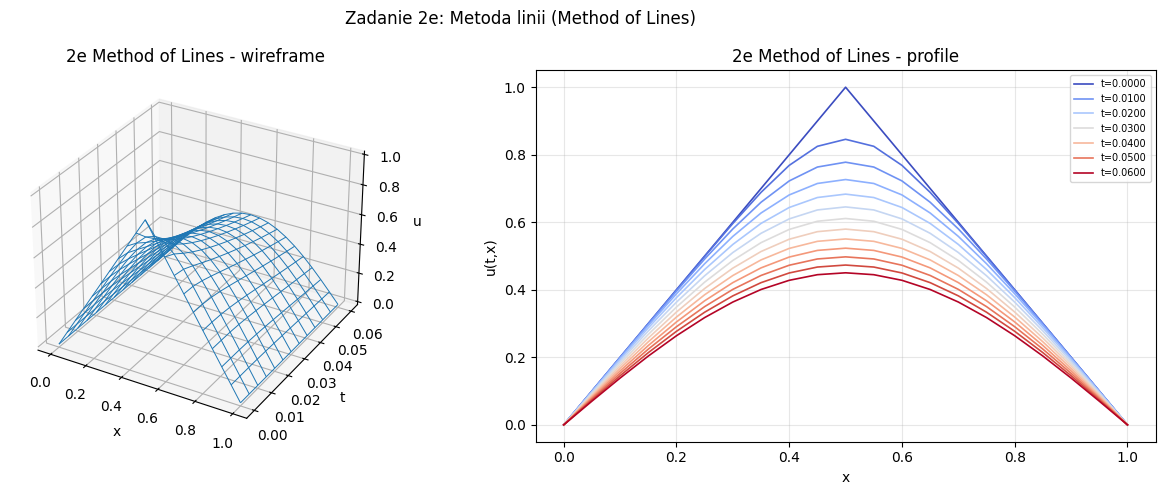

In [11]:
# 2e - Metoda linii (Method of Lines)
from scipy.integrate import solve_ivp

def solve_method_of_lines(dx, dt, T_end):
    xs = np.arange(0, 1 + dx/2, dx)
    Nx = len(xs)
    N_int = Nx - 2
    print(f"  dx={dx}, dt={dt} (Metoda linii)")

    # Macierz pochodnej przestrzennej
    d_main = np.full(N_int, -2.0 / dx**2)
    d_off  = np.full(N_int - 1, 1.0 / dx**2)
    A_ode = diags([d_off, d_main, d_off], [-1, 0, 1], format="csr")

    def ode_system(t, y):
        return A_ode.dot(y)

    y0 = heat_init(xs)[1:-1]
    t_eval = np.arange(0, T_end + dt/2, dt)

    # Uklad moze byc sztywny, uzywamy odpowiedniego solwera (np. Radau)
    sol = solve_ivp(ode_system, [0, T_end], y0, method="Radau", t_eval=t_eval)

    Nt = len(t_eval)
    U = np.zeros((Nt, Nx))
    # sol.y ma ksztalt (N_int, Nt) -> transponujemy
    U[:, 1:-1] = sol.y.T
    U[:, 0] = U[:, -1] = 0.0

    return xs, U, t_eval

print("=== 2e: Metoda linii (dt=0.005) ===")
xs_e, U_e, ts_e = solve_method_of_lines(dx, dt_cn, T_end)

steps_e = list(range(U_e.shape[0]))

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121, projection="3d")
Xme, Tme = np.meshgrid(xs_e, ts_e[steps_e])
ax1.plot_wireframe(Xme, Tme, U_e[steps_e, :], rstride=1, cstride=1, linewidth=0.7)
ax1.set_xlabel("x"); ax1.set_ylabel("t"); ax1.set_zlabel("u")
ax1.set_title(f"2e Method of Lines - wireframe")

ax2 = fig.add_subplot(122)
colors5 = plt.cm.coolwarm(np.linspace(0, 1, len(steps_e)))
for idx, (s, c) in enumerate(zip(steps_e, colors5)):
    lbl = f"t={ts_e[s]:.4f}" if idx % 2 == 0 else ""
    ax2.plot(xs_e, U_e[s], color=c, lw=1.2, label=lbl)
ax2.set_xlabel("x"); ax2.set_ylabel("u(t,x)")
ax2.set_title(f"2e Method of Lines - profile")
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

plt.suptitle("Zadanie 2e: Metoda linii (Method of Lines)", fontsize=12)
plt.tight_layout(); plt.show()

Maksymalne roznice miedzy rozwiazaniami dla t = 0.06:
  Implicit Euler vs Crank-Nicolson: 7.159120e-03
  Implicit Euler vs Method of Lines: 7.086685e-03
  Crank-Nicolson vs Method of Lines: 1.121884e-04


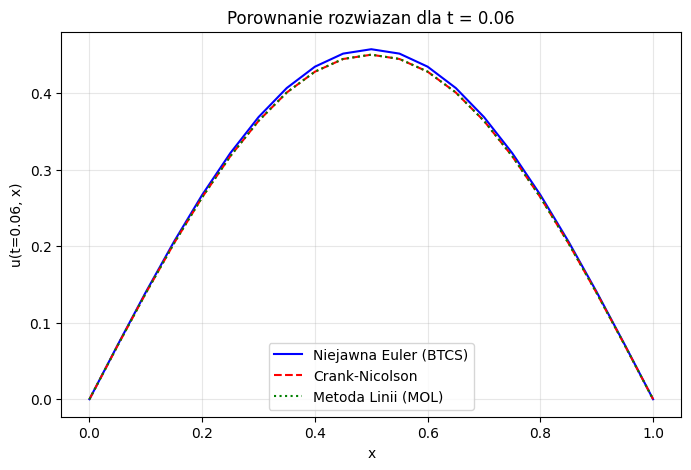

In [12]:
# Porownanie metod w punkcie t = 0.06
# Sprawdzamy maksymalne roznice miedzy rozwiazaniami w koncowym momencie czasu

t_idx = -1 # ostatni krok czasowy t = 0.06

diff_imp_cn = np.max(np.abs(U_c[t_idx] - U_d[t_idx]))
diff_imp_mol = np.max(np.abs(U_c[t_idx] - U_e[t_idx]))
diff_cn_mol = np.max(np.abs(U_d[t_idx] - U_e[t_idx]))

print("Maksymalne roznice miedzy rozwiazaniami dla t = 0.06:")
print(f"  Implicit Euler vs Crank-Nicolson: {diff_imp_cn:.6e}")
print(f"  Implicit Euler vs Method of Lines: {diff_imp_mol:.6e}")
print(f"  Crank-Nicolson vs Method of Lines: {diff_cn_mol:.6e}")

# Wykres porownawczy dla t = 0.06
plt.figure(figsize=(8, 5))
plt.plot(xs_c, U_c[t_idx], "b-", label="Niejawna Euler (BTCS)")
plt.plot(xs_d, U_d[t_idx], "r--", label="Crank-Nicolson")
plt.plot(xs_e, U_e[t_idx], "g:", label="Metoda Linii (MOL)")
plt.xlabel("x")
plt.ylabel("u(t=0.06, x)")
plt.title("Porownanie rozwiazan dla t = 0.06")
plt.legend()
plt.grid(True, alpha=0.3)

# Zapisanie wykresow do sprawozdania
# Zapisujemy profil i wireframe niejawnej Eulera (dt=0.005)
fig_c = plt.figure(figsize=(13, 5))
ax1_c = fig_c.add_subplot(121, projection="3d")
ax1_c.plot_wireframe(Xmc, Tmc, U_c[steps_c, :], rstride=1, cstride=1, linewidth=0.7)
ax1_c.set_xlabel("x"); ax1_c.set_ylabel("t"); ax1_c.set_zlabel("u")
ax1_c.set_title("Niejawna metoda Eulera - wireframe")
ax2_c = fig_c.add_subplot(122)
colors3 = plt.cm.coolwarm(np.linspace(0, 1, len(steps_c)))
for idx, (s, c) in enumerate(zip(steps_c, colors3)):
    lbl = f"t={ts_c[s]:.4f}" if idx % 2 == 0 else ""
    ax2_c.plot(xs_c, U_c[s], color=c, lw=1.2, label=lbl)
ax2_c.set_xlabel("x"); ax2_c.set_ylabel("u(t,x)")
ax2_c.set_title("Niejawna metoda Eulera - profile")
ax2_c.legend(fontsize=7); ax2_c.grid(True, alpha=0.3)
fig_c.tight_layout()
fig_c.savefig("sprawozdanie/wykres7.png", dpi=150)
plt.close(fig_c)

# Zapisujemy profil i wireframe dla Crank-Nicolson
fig_d = plt.figure(figsize=(13, 5))
ax1_d = fig_d.add_subplot(121, projection="3d")
ax1_d.plot_wireframe(Xmd, Tmd, U_d[steps_d, :], rstride=1, cstride=1, linewidth=0.7)
ax1_d.set_xlabel("x"); ax1_d.set_ylabel("t"); ax1_d.set_zlabel("u")
ax1_d.set_title("Metoda Cranka-Nicolson - wireframe")
ax2_d = fig_d.add_subplot(122)
for idx, (s, c) in enumerate(zip(steps_d, colors4)):
    lbl = f"t={ts_d[s]:.4f}" if idx % 2 == 0 else ""
    ax2_d.plot(xs_d, U_d[s], color=c, lw=1.2, label=lbl)
ax2_d.set_xlabel("x"); ax2_d.set_ylabel("u(t,x)")
ax2_d.set_title("Metoda Cranka-Nicolson - profile")
ax2_d.legend(fontsize=7); ax2_d.grid(True, alpha=0.3)
fig_d.tight_layout()
fig_d.savefig("sprawozdanie/wykres8.png", dpi=150)
plt.close(fig_d)

# Zapisujemy profil i wireframe dla metody linii
fig_e = plt.figure(figsize=(13, 5))
ax1_e = fig_e.add_subplot(121, projection="3d")
ax1_e.plot_wireframe(Xme, Tme, U_e[steps_e, :], rstride=1, cstride=1, linewidth=0.7)
ax1_e.set_xlabel("x"); ax1_e.set_ylabel("t"); ax1_e.set_zlabel("u")
ax1_e.set_title("Metoda linii (MOL) - wireframe")
ax2_e = fig_e.add_subplot(122)
for idx, (s, c) in enumerate(zip(steps_e, colors5)):
    lbl = f"t={ts_e[s]:.4f}" if idx % 2 == 0 else ""
    ax2_e.plot(xs_e, U_e[s], color=c, lw=1.2, label=lbl)
ax2_e.set_xlabel("x"); ax2_e.set_ylabel("u(t,x)")
ax2_e.set_title("Metoda linii (MOL) - profile")
ax2_e.legend(fontsize=7); ax2_e.grid(True, alpha=0.3)
fig_e.tight_layout()
fig_e.savefig("sprawozdanie/wykres9.png", dpi=150)
plt.close(fig_e)

plt.show()
